# Data Preparation

In [1]:
from typing import Union, Iterable
from dataclasses import dataclass
import json

with open("data/stopwords.json", "r") as file:
    stopwords = json.load(file)


def get_dataset(filepath: str):
    with open(filepath, "r") as file:
        dataset = json.load(file)
    labels: list[str] = [item["label"] for item in dataset]
    tasks: list[str] = [item["task"] for item in dataset]
    descs: list[str] = [" ".join(item["high_descs"]) for item in dataset]
    return {"labels": labels, "tasks": tasks, "descs": descs}


class dataset:
    def __init__(self, filepath: str):
        data = get_dataset(filepath)
        self.labels: list[str] = data["labels"]
        self.tasks: list[str] = data["tasks"]
        self.descs: list[str] = data["descs"]

    def text(self, on_desc: bool = False):
        return self.descs if on_desc else self.tasks

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics import classification_report, accuracy_score
from sklearn.metrics.pairwise import cosine_similarity


class Experiment:
    def __init__(
        self, train_filepath: str, test_seen_filepath: str, test_unseen_filepath: str
    ):
        self.train = dataset(train_filepath)
        self.test_seen = dataset(test_seen_filepath)
        self.test_unseen = dataset(test_unseen_filepath)
        # vectorize labels
        self.labelEncoder = LabelEncoder()
        self.train.label_idx = self.labelEncoder.fit_transform(self.train.labels)
        self.test_seen.label_idx = self.labelEncoder.transform(self.test_seen.labels)
        self.test_unseen.label_idx = self.labelEncoder.transform(
            self.test_unseen.labels
        )
        self.labels = self.labelEncoder.classes_

    def vectorize(
        self,
        vectorizer: Union[CountVectorizer, TfidfVectorizer],
        on_desc: bool = False,
    ):
        self.on_desc = on_desc
        self.vectorizer = vectorizer
        self.X_train = self.vectorizer.fit_transform(self.train.text(on_desc))
        self.X_test_seen = self.vectorizer.transform(self.test_seen.text(on_desc))
        self.X_test_unseen = self.vectorizer.transform(self.test_unseen.text(on_desc))

    def encode(self, model, on_desc: bool = False):
        self.on_desc = on_desc
        self.vectorizer = model
        self.X_train = self.vectorizer.encode(
            self.train.text(on_desc), show_progress_bar=True
        )
        self.X_test_seen = self.vectorizer.encode(
            self.test_seen.text(on_desc), show_progress_bar=True
        )
        self.X_test_unseen = self.vectorizer.encode(
            self.test_unseen.text(on_desc), show_progress_bar=True
        )

    def baseline(self, eps: float = 0.1):
        num_labels = len(self.labels)
        num_features = self.X_train.shape[1]
        self.X_label = np.zeros((num_labels, num_features))
        for i in range(num_labels):
            self.X_label[i, :] = self.X_train[self.train.label_idx == i].sum(axis=0)
        label_logProb = np.log(self.X_label + eps)
        print(
            "===== BoW Performance on Seen Data Using Probability ====="
        )
        bow_seen = np.argmax(self.X_test_seen @ label_logProb.T, axis=1)
        print(classification_report(self.test_seen.label_idx, bow_seen, digits=4))
        print(
            "==== BoW Performance on Unseen Data Using Probability ===="
        )
        bow_unseen = np.argmax(self.X_test_unseen @ label_logProb.T, axis=1)
        print(classification_report(self.test_unseen.label_idx, bow_unseen, digits=4))
        print(
            "====== BoW Performance on Seen Data Using Similarity ======"
        )
        sim_seen = np.argmax(cosine_similarity(self.X_test_seen, self.X_label), axis=1)
        print(classification_report(self.test_seen.label_idx, sim_seen, digits=4))
        print(
            "===== BoW Performance on UnSeen Data Using Similarity ====="
        )
        sim_unseen = np.argmax(
            cosine_similarity(self.X_test_unseen, self.X_label), axis=1
        )
        print(classification_report(self.test_unseen.label_idx, sim_unseen, digits=4))

    def classify(self, classifier):
        self.classifier = classifier
        self.classifier.fit(self.X_train, self.train.label_idx)
        self.pred_seen = self.classifier.predict(self.X_test_seen)
        self.pred_unseen = self.classifier.predict(self.X_test_unseen)

    def score(self, metric, is_seen=False, **args):
        label = self.test_seen.label_idx if is_seen else self.test_unseen.label_idx
        pred = self.pred_seen if is_seen else self.pred_unseen
        return metric(label, pred, **args)

    @dataclass
    class SweepOutput:
        value: list
        seen: list
        unseen: list

    def sweep(self, classifier, param: str, values: Iterable, metric, **args):
        output_seen = []
        output_unseen = []
        for value in values:
            self.classify(classifier.set_params(**{param: value}))
            output_seen.append(self.score(metric, True, **args))
            output_unseen.append(self.score(metric, False, **args))
        self.sweep_output = self.SweepOutput(values, output_seen, output_unseen)
        return self.sweep_output

    def sweep_plot(self, ax):
        ax.plot(
            self.sweep_output.value,
            self.sweep_output.seen,
            label="Desc (Seen)" if self.on_desc else "Task (Seen)",
            color="royalblue" if self.on_desc else "crimson",
            marker="o",
            linestyle="-",
        )
        ax.plot(
            self.sweep_output.value,
            self.sweep_output.unseen,
            label="Desc (UnSeen)" if self.on_desc else "Task (Seen)",
            color="royalblue" if self.on_desc else "crimson",
            marker="s",
            linestyle="--",
        )

# Experiment

In [3]:
import copy

exp_task = Experiment(
    *[f"./data/alfred/{x}.json" for x in ["train", "valid_seen", "valid_unseen"]]
)
exp_desc = copy.copy(exp_task)
exp_task.vectorize(CountVectorizer(stop_words=stopwords))
exp_desc.vectorize(CountVectorizer(stop_words=stopwords), on_desc=True)

## Baseline

Baseline performance on task texts

In [14]:
exp_task.baseline()

===== BoW Performance on Seen Data Using Probability =====
              precision    recall  f1-score   support

           0     0.9892    0.9787    0.9840        94
           1     0.9438    0.5915    0.7273       142
           2     0.6531    0.8348    0.7328       115
           3     0.8750    0.9375    0.9052       112
           4     0.8115    0.7857    0.7984       126
           5     0.8130    0.9346    0.8696       107
           6     0.9206    0.9355    0.9280       124

    accuracy                         0.8439       820
   macro avg     0.8580    0.8569    0.8493       820
weighted avg     0.8579    0.8439    0.8416       820

==== BoW Performance on Unseen Data Using Probability ====
              precision    recall  f1-score   support

           0     1.0000    0.9942    0.9971       173
           1     0.8219    0.6000    0.6936       100
           2     0.9000    0.8257    0.8612       109
           3     0.9643    0.9558    0.9600       113
           4  

Baseline performance on step descriptions

In [15]:
exp_desc.baseline()

===== BoW Performance on Seen Data Using Probability =====
              precision    recall  f1-score   support

           0     1.0000    0.0106    0.0211        94
           1     1.0000    0.0070    0.0140       142
           2     0.6952    0.6348    0.6636       115
           3     1.0000    0.5268    0.6901       112
           4     0.7845    0.7222    0.7521       126
           5     0.6481    0.9813    0.7807       107
           6     0.2899    0.8790    0.4360       124

    accuracy                         0.5354       820
   macro avg     0.7740    0.5374    0.4796       820
weighted avg     0.7708    0.5354    0.4755       820

==== BoW Performance on Unseen Data Using Probability ====
              precision    recall  f1-score   support

           0     1.0000    0.0173    0.0341       173
           1     0.0000    0.0000    0.0000       100
           2     0.8471    0.6606    0.7423       109
           3     1.0000    0.5664    0.7232       113
           4  

d:\Code\CSE4601\project\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Code\CSE4601\project\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Code\CSE4601\project\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


## TF-IDF vector with different classifiers 

In [16]:
exp_task.vectorize(TfidfVectorizer(stop_words=list(stopwords)))
exp_desc.vectorize(TfidfVectorizer(stop_words=list(stopwords)), on_desc=True)

### Support Vector Machine

In [17]:
from sklearn.svm import LinearSVC

exp_task.classify(LinearSVC())
print("============== SVM Performance on Seen Task Data ==============")
print(exp_task.score(classification_report, True, digits=4))
print("============= SVM Performance on Unseen Task Data =============")
print(exp_task.score(classification_report, False, digits=4))

exp_desc.classify(LinearSVC())
print("============== SVM Performance on Seen Desc Data ==============")
print(exp_desc.score(classification_report, True, digits=4))
print("============= SVM Performance on Unseen Desc Data =============")
print(exp_desc.score(classification_report, False, digits=4))

============== SVM Performance on Seen Task Data ==============
              precision    recall  f1-score   support

           0     0.9892    0.9787    0.9840        94
           1     0.8929    0.8803    0.8865       142
           2     0.8015    0.9478    0.8685       115
           3     0.9730    0.9643    0.9686       112
           4     0.9316    0.8651    0.8971       126
           5     0.9429    0.9252    0.9340       107
           6     0.9831    0.9355    0.9587       124

    accuracy                         0.9244       820
   macro avg     0.9306    0.9281    0.9282       820
weighted avg     0.9282    0.9244    0.9251       820

============= SVM Performance on Unseen Task Data =============
              precision    recall  f1-score   support

           0     1.0000    0.9884    0.9942       173
           1     0.8468    0.9400    0.8910       100
           2     0.9358    0.9358    0.9358       109
           3     0.9821    0.9735    0.9778       113
    

### Logistic Regression

In [18]:
from sklearn.linear_model import LogisticRegression

exp_task.classify(LogisticRegression(max_iter=200))
print("======== Logistic Regression Performance on Seen Task Data ========")
print(exp_task.score(classification_report, True, digits=4))
print("======= Logistic Regression Performance on Unseen Task Data =======")
print(exp_task.score(classification_report, False, digits=4))

exp_desc.classify(LogisticRegression(max_iter=200))
print("======== Logistic Regression Performance on Seen Desc Data ========")
print(exp_desc.score(classification_report, True, digits=4))
print("======= Logistic Regression Performance on Unseen Desc Data =======")
print(exp_desc.score(classification_report, False, digits=4))

======== Logistic Regression Performance on Seen Task Data ========
              precision    recall  f1-score   support

           0     1.0000    0.9787    0.9892        94
           1     0.8971    0.8592    0.8777       142
           2     0.7971    0.9565    0.8696       115
           3     0.9643    0.9643    0.9643       112
           4     0.9237    0.8651    0.8934       126
           5     0.9439    0.9439    0.9439       107
           6     0.9829    0.9274    0.9544       124

    accuracy                         0.9232       820
   macro avg     0.9299    0.9279    0.9275       820
weighted avg     0.9272    0.9232    0.9238       820

======= Logistic Regression Performance on Unseen Task Data =======
              precision    recall  f1-score   support

           0     1.0000    0.9884    0.9942       173
           1     0.8053    0.9100    0.8545       100
           2     0.9515    0.8991    0.9245       109
           3     0.9725    0.9381    0.9550       

### Random Forest


In [19]:
from sklearn.ensemble import RandomForestClassifier

args = {
    "classifier": RandomForestClassifier(),
    "param": "n_estimators",
    "values": np.arange(10, 101, 10),
    "metric": accuracy_score,
}
output_task = exp_task.sweep(**args)
output_desc = exp_desc.sweep(**args)

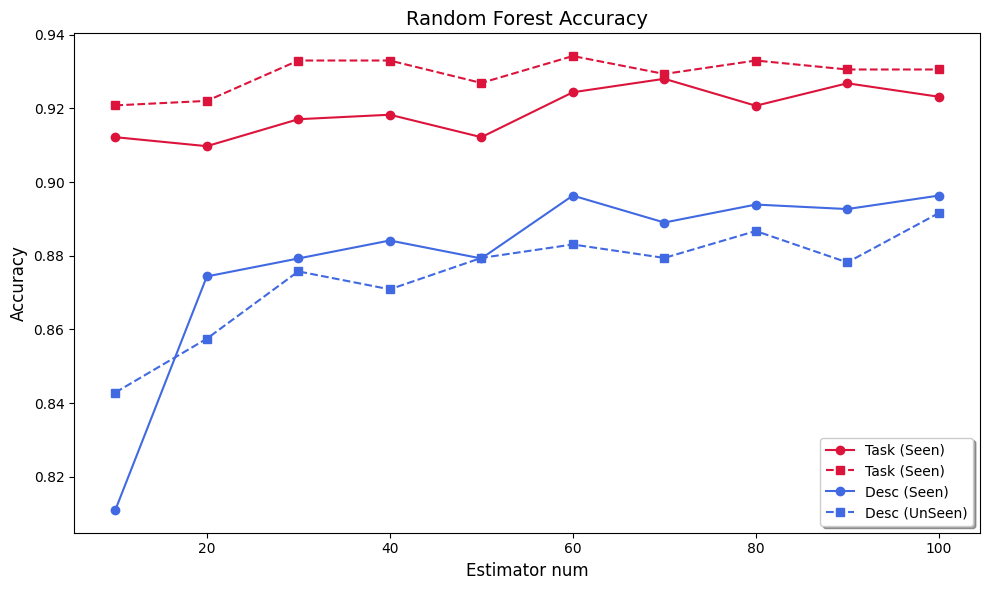

In [20]:
fig, ax = plt.subplots(figsize=(10, 6))
exp_task.sweep_plot(ax)
exp_desc.sweep_plot(ax)
ax.set_title("Random Forest Accuracy", fontsize=14)
ax.set_xlabel("Estimator num", fontsize=12)
ax.set_ylabel("Accuracy", fontsize=12)
ax.legend(frameon=True, shadow=True, loc="best")
plt.tight_layout()
plt.show()

In [21]:
exp_task.classify(RandomForestClassifier(n_estimators=200))
print("======== Random Forest Performance on Seen Task Data ========")
print(exp_task.score(classification_report, True, digits=4))
print("======= Random Forest Performance on Unseen Task Data =======")
print(exp_task.score(classification_report, False, digits=4))

exp_desc.classify(RandomForestClassifier(n_estimators=200))
print("======== Random Forest Performance on Seen Desc Data ========")
print(exp_desc.score(classification_report, True, digits=4))
print("======= Random Forest Performance on Unseen Desc Data =======")
print(exp_desc.score(classification_report, False, digits=4))

======== Random Forest Performance on Seen Task Data ========
              precision    recall  f1-score   support

           0     1.0000    0.9787    0.9892        94
           1     0.8591    0.9014    0.8797       142
           2     0.8438    0.9391    0.8889       115
           3     0.9554    0.9554    0.9554       112
           4     0.9558    0.8571    0.9038       126
           5     0.8957    0.9626    0.9279       107
           6     1.0000    0.8952    0.9447       124

    accuracy                         0.9232       820
   macro avg     0.9299    0.9271    0.9271       820
weighted avg     0.9272    0.9232    0.9237       820

======= Random Forest Performance on Unseen Task Data =======
              precision    recall  f1-score   support

           0     1.0000    0.9884    0.9942       173
           1     0.8269    0.8600    0.8431       100
           2     0.8889    0.9541    0.9204       109
           3     0.9815    0.9381    0.9593       113
        

### K Neighbors

In [22]:
from sklearn.neighbors import KNeighborsClassifier

args = {
    "classifier": KNeighborsClassifier(),
    "param": "n_neighbors",
    "values": np.arange(1, 11, 1),
    "metric": accuracy_score,
}
output_task = exp_task.sweep(**args)
output_desc = exp_desc.sweep(**args)

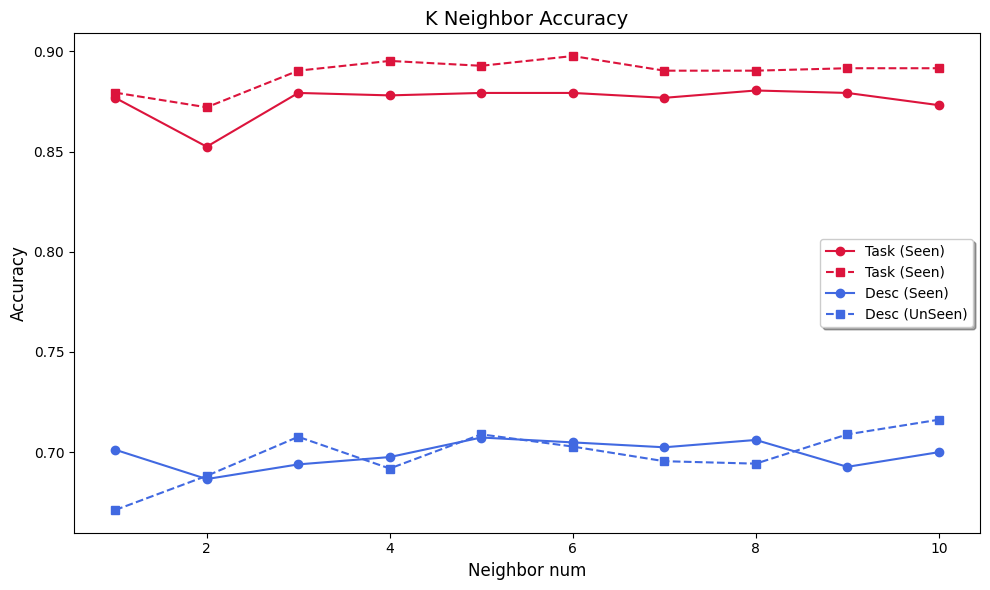

In [23]:
fig, ax = plt.subplots(figsize=(10, 6))
exp_task.sweep_plot(ax)
exp_desc.sweep_plot(ax)
ax.set_title("K Neighbor Accuracy", fontsize=14)
ax.set_xlabel("Neighbor num", fontsize=12)
ax.set_ylabel("Accuracy", fontsize=12)
ax.legend(frameon=True, shadow=True, loc="best")
plt.tight_layout()
plt.show()

In [24]:
exp_task.classify(KNeighborsClassifier(n_neighbors=5))
print("======== K-Neighbors Performance on Seen Task Data ========")
print(exp_task.score(classification_report, True, digits=4))
print("======= K-Neighbors Performance on Unseen Task Data =======")
print(exp_task.score(classification_report, False, digits=4))

exp_desc.classify(KNeighborsClassifier(n_neighbors=5))
print("======== K-Neighbors Performance on Seen Desc Data ========")
print(exp_desc.score(classification_report, True, digits=4))
print("======= K-Neighbors Performance on Unseen Desc Data =======")
print(exp_desc.score(classification_report, False, digits=4))

======== K-Neighbors Performance on Seen Task Data ========
              precision    recall  f1-score   support

           0     1.0000    0.9787    0.9892        94
           1     0.7877    0.8099    0.7986       142
           2     0.7698    0.8435    0.8050       115
           3     0.8729    0.9196    0.8957       112
           4     0.9292    0.8333    0.8787       126
           5     0.9174    0.9346    0.9259       107
           6     0.9397    0.8790    0.9083       124

    accuracy                         0.8793       820
   macro avg     0.8881    0.8855    0.8859       820
weighted avg     0.8828    0.8793    0.8801       820

======= K-Neighbors Performance on Unseen Task Data =======
              precision    recall  f1-score   support

           0     0.9773    0.9942    0.9857       173
           1     0.7073    0.8700    0.7803       100
           2     0.9022    0.7615    0.8259       109
           3     0.9340    0.8761    0.9041       113
           4

### MLP Classifier

In [13]:
# from sklearn.neural_network import MLPClassifier

# args = {
#     "classifier": MLPClassifier(
#         hidden_layer_sizes=(256, 128), activation="relu", random_state=42
#     ),
#     "param": "max_iter",
#     "values": np.arange(100, 501, 100),
#     "metric": accuracy_score,
# }
# output_task = exp_task.sweep(**args)
# output_desc = exp_desc.sweep(**args)

In [14]:
# fig, ax = plt.subplots(figsize=(10, 6))
# exp_task.sweep_plot(ax)
# exp_desc.sweep_plot(ax)
# ax.set_title("MLP Classifier Accuracy", fontsize=14)
# ax.set_xlabel("Iteration Num", fontsize=12)
# ax.set_ylabel("Accuracy", fontsize=12)
# ax.legend(frameon=True, shadow=True, loc="best")
# plt.tight_layout()
# plt.show()

In [25]:
from sklearn.neural_network import MLPClassifier

exp_task.classify(
    MLPClassifier(hidden_layer_sizes=(256, 128), activation="relu", max_iter=200)
)
print("========== MLP Performance on Seen Task Data ==========")
print(exp_task.score(classification_report, True, digits=4))
print("========= MLP Performance on Unseen Task Data =========")
print(exp_task.score(classification_report, False, digits=4))
exp_desc.classify(
    MLPClassifier(hidden_layer_sizes=(256, 128), activation="relu", max_iter=200)
)
print("========== MLP Performance on Seen Desc Data ==========")
print(exp_desc.score(classification_report, True, digits=4))
print("========= MLP Performance on Unseen Desc Data =========")
print(exp_desc.score(classification_report, False, digits=4))

========== MLP Performance on Seen Task Data ==========
              precision    recall  f1-score   support

           0     0.9892    0.9787    0.9840        94
           1     0.9000    0.9507    0.9247       142
           2     0.9196    0.8957    0.9075       115
           3     0.9474    0.9643    0.9558       112
           4     0.9224    0.8492    0.8843       126
           5     0.8860    0.9439    0.9140       107
           6     0.9669    0.9435    0.9551       124

    accuracy                         0.9305       820
   macro avg     0.9331    0.9323    0.9322       820
weighted avg     0.9312    0.9305    0.9303       820

========= MLP Performance on Unseen Task Data =========
              precision    recall  f1-score   support

           0     1.0000    0.9884    0.9942       173
           1     0.8396    0.8900    0.8641       100
           2     0.9783    0.8257    0.8955       109
           3     0.9492    0.9912    0.9697       113
           4     0.9

## Pre-trained Transformer

In [4]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("all-MiniLM-L6-v2")

exp_task.encode(model, False)
exp_desc.encode(model, True)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/658 [00:00<?, ?it/s]

Batches:   0%|          | 0/26 [00:00<?, ?it/s]

Batches:   0%|          | 0/26 [00:00<?, ?it/s]

Batches:   0%|          | 0/658 [00:00<?, ?it/s]

Batches:   0%|          | 0/26 [00:00<?, ?it/s]

Batches:   0%|          | 0/26 [00:00<?, ?it/s]

### Support Vector Machine

In [5]:
from sklearn.svm import LinearSVC

exp_task.classify(LinearSVC())
print("============== SVM Performance on Seen Task Data ==============")
print(exp_task.score(classification_report, True, digits=4))
print("============= SVM Performance on Unseen Task Data =============")
print(exp_task.score(classification_report, False, digits=4))

exp_desc.classify(LinearSVC())
print("============== SVM Performance on Seen Desc Data ==============")
print(exp_desc.score(classification_report, True, digits=4))
print("============= SVM Performance on Unseen Desc Data =============")
print(exp_desc.score(classification_report, False, digits=4))

============== SVM Performance on Seen Task Data ==============
              precision    recall  f1-score   support

           0     1.0000    0.9787    0.9892        94
           1     0.8732    0.8732    0.8732       142
           2     0.8385    0.9478    0.8898       115
           3     0.9304    0.9554    0.9427       112
           4     0.9375    0.8333    0.8824       126
           5     0.9273    0.9533    0.9401       107
           6     0.9664    0.9274    0.9465       124

    accuracy                         0.9195       820
   macro avg     0.9248    0.9242    0.9234       820
weighted avg     0.9217    0.9195    0.9196       820

============= SVM Performance on Unseen Task Data =============
              precision    recall  f1-score   support

           0     0.9942    0.9884    0.9913       173
           1     0.8571    0.8400    0.8485       100
           2     0.8860    0.9266    0.9058       109
           3     0.9558    0.9558    0.9558       113
    

### Logistic Regression

In [6]:
from sklearn.linear_model import LogisticRegression

exp_task.classify(LogisticRegression(max_iter=200))
print("======== Logistic Regression Performance on Seen Task Data ========")
print(exp_task.score(classification_report, True, digits=4))
print("======= Logistic Regression Performance on Unseen Task Data =======")
print(exp_task.score(classification_report, False, digits=4))

exp_desc.classify(LogisticRegression(max_iter=200))
print("======== Logistic Regression Performance on Seen Desc Data ========")
print(exp_desc.score(classification_report, True, digits=4))
print("======= Logistic Regression Performance on Unseen Desc Data =======")
print(exp_desc.score(classification_report, False, digits=4))

======== Logistic Regression Performance on Seen Task Data ========
              precision    recall  f1-score   support

           0     1.0000    0.9787    0.9892        94
           1     0.8712    0.8099    0.8394       142
           2     0.8045    0.9304    0.8629       115
           3     0.9068    0.9554    0.9304       112
           4     0.9450    0.8175    0.8766       126
           5     0.8718    0.9533    0.9107       107
           6     0.9580    0.9194    0.9383       124

    accuracy                         0.9024       820
   macro avg     0.9082    0.9092    0.9068       820
weighted avg     0.9060    0.9024    0.9023       820

======= Logistic Regression Performance on Unseen Task Data =======
              precision    recall  f1-score   support

           0     1.0000    0.9884    0.9942       173
           1     0.8485    0.8400    0.8442       100
           2     0.8632    0.9266    0.8938       109
           3     0.9386    0.9469    0.9427       

### Random Forest


In [7]:
from sklearn.ensemble import RandomForestClassifier

args = {
    "classifier": RandomForestClassifier(),
    "param": "n_estimators",
    "values": np.arange(5, 51, 5),
    "metric": accuracy_score,
}
output_task = exp_task.sweep(**args)
output_desc = exp_desc.sweep(**args)

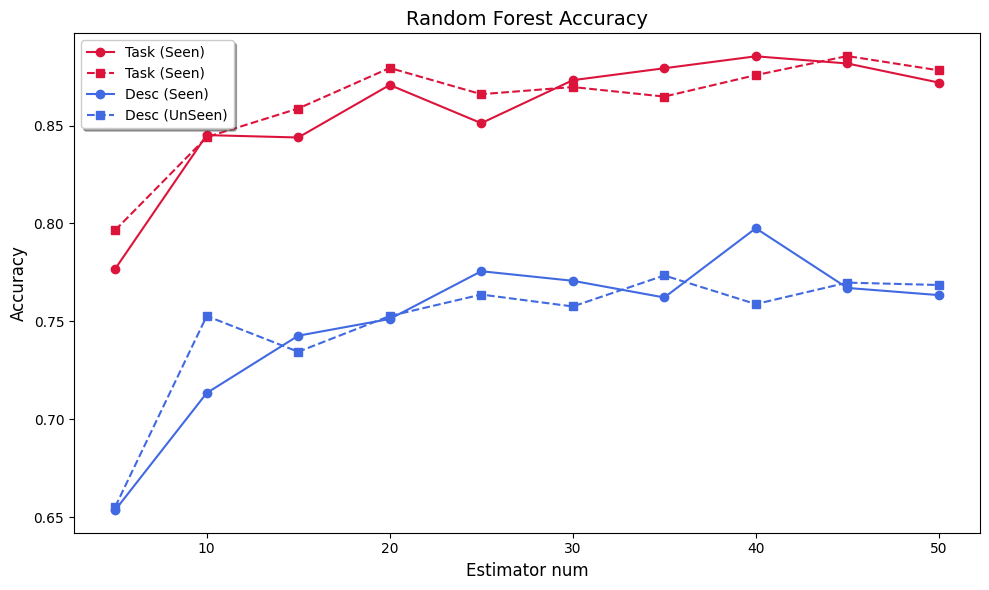

In [8]:
fig, ax = plt.subplots(figsize=(10, 6))
exp_task.sweep_plot(ax)
exp_desc.sweep_plot(ax)
ax.set_title("Random Forest Accuracy", fontsize=14)
ax.set_xlabel("Estimator num", fontsize=12)
ax.set_ylabel("Accuracy", fontsize=12)
ax.legend(frameon=True, shadow=True, loc="best")
plt.tight_layout()
plt.show()

In [9]:
exp_task.classify(RandomForestClassifier(n_estimators=200))
print("======== Random Forest Performance on Seen Task Data ========")
print(exp_task.score(classification_report, True, digits=4))
print("======= Random Forest Performance on Unseen Task Data =======")
print(exp_task.score(classification_report, False, digits=4))

exp_desc.classify(RandomForestClassifier(n_estimators=200))
print("======== Random Forest Performance on Seen Desc Data ========")
print(exp_desc.score(classification_report, True, digits=4))
print("======= Random Forest Performance on Unseen Desc Data =======")
print(exp_desc.score(classification_report, False, digits=4))

======== Random Forest Performance on Seen Task Data ========
              precision    recall  f1-score   support

           0     1.0000    0.9787    0.9892        94
           1     0.8702    0.8028    0.8352       142
           2     0.7660    0.9391    0.8438       115
           3     0.8983    0.9464    0.9217       112
           4     0.9806    0.8016    0.8821       126
           5     0.8525    0.9720    0.9083       107
           6     0.9646    0.8790    0.9198       124

    accuracy                         0.8951       820
   macro avg     0.9046    0.9028    0.9000       820
weighted avg     0.9032    0.8951    0.8954       820

======= Random Forest Performance on Unseen Task Data =======
              precision    recall  f1-score   support

           0     1.0000    0.9884    0.9942       173
           1     0.8734    0.6900    0.7709       100
           2     0.8033    0.8991    0.8485       109
           3     0.9204    0.9204    0.9204       113
        

### K Neighbors

In [10]:
from sklearn.neighbors import KNeighborsClassifier

args = {
    "classifier": KNeighborsClassifier(),
    "param": "n_neighbors",
    "values": np.arange(1, 11, 1),
    "metric": accuracy_score,
}
output_task = exp_task.sweep(**args)
output_desc = exp_desc.sweep(**args)

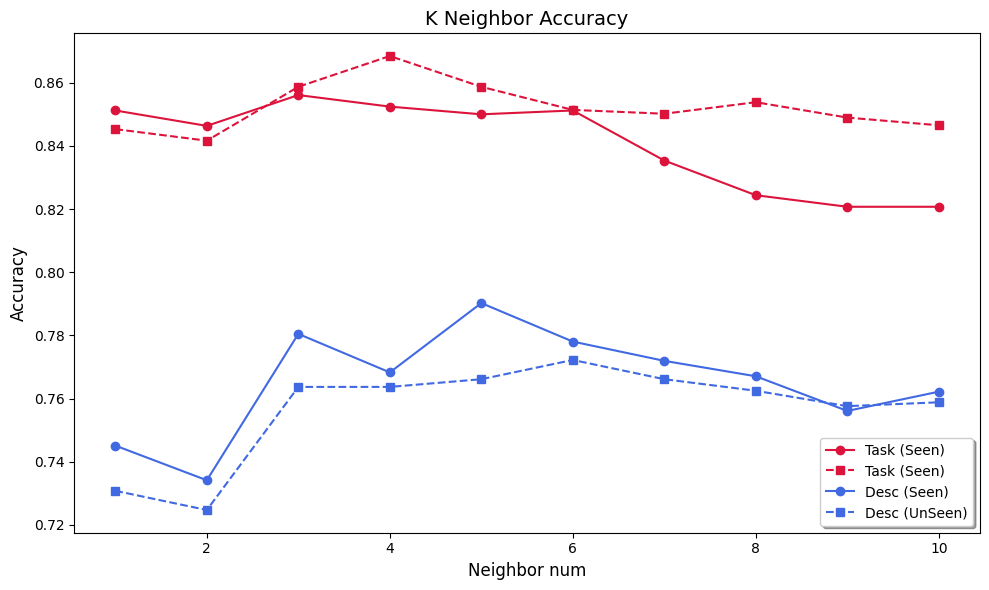

In [11]:
fig, ax = plt.subplots(figsize=(10, 6))
exp_task.sweep_plot(ax)
exp_desc.sweep_plot(ax)
ax.set_title("K Neighbor Accuracy", fontsize=14)
ax.set_xlabel("Neighbor num", fontsize=12)
ax.set_ylabel("Accuracy", fontsize=12)
ax.legend(frameon=True, shadow=True, loc="best")
plt.tight_layout()
plt.show()

In [12]:
exp_task.classify(KNeighborsClassifier(n_neighbors=5))
print("======== K-Neighbors Performance on Seen Task Data ========")
print(exp_task.score(classification_report, True, digits=4))
print("======= K-Neighbors Performance on Unseen Task Data =======")
print(exp_task.score(classification_report, False, digits=4))

exp_desc.classify(KNeighborsClassifier(n_neighbors=5))
print("======== K-Neighbors Performance on Seen Desc Data ========")
print(exp_desc.score(classification_report, True, digits=4))
print("======= K-Neighbors Performance on Unseen Desc Data =======")
print(exp_desc.score(classification_report, False, digits=4))

======== K-Neighbors Performance on Seen Task Data ========
              precision    recall  f1-score   support

           0     1.0000    0.9787    0.9892        94
           1     0.7955    0.7394    0.7664       142
           2     0.7953    0.8783    0.8347       115
           3     0.8016    0.9018    0.8487       112
           4     0.9588    0.7381    0.8341       126
           5     0.8443    0.9626    0.8996       107
           6     0.8226    0.8226    0.8226       124

    accuracy                         0.8500       820
   macro avg     0.8597    0.8602    0.8565       820
weighted avg     0.8553    0.8500    0.8490       820

======= K-Neighbors Performance on Unseen Task Data =======
              precision    recall  f1-score   support

           0     1.0000    0.9884    0.9942       173
           1     0.7158    0.6800    0.6974       100
           2     0.8716    0.8716    0.8716       109
           3     0.9009    0.8850    0.8929       113
           4

### MLP Classifier

In [13]:
from sklearn.neural_network import MLPClassifier

exp_task.classify(
    MLPClassifier(hidden_layer_sizes=(256, 128), activation="relu", max_iter=200)
)
print("============== MLP Performance on Seen Task Data ==============")
print(exp_task.score(classification_report, True, digits=4))
print("============= MLP Performance on Unseen Task Data =============")
print(exp_task.score(classification_report, False, digits=4))
exp_desc.classify(
    MLPClassifier(hidden_layer_sizes=(256, 128), activation="relu", max_iter=200)
)
print("============== MLP Performance on Seen Desc Data ==============")
print(exp_desc.score(classification_report, True, digits=4))
print("============= MLP Performance on Unseen Desc Data =============")
print(exp_desc.score(classification_report, False, digits=4))

============== MLP Performance on Seen Task Data ==============
              precision    recall  f1-score   support

           0     0.9684    0.9787    0.9735        94
           1     0.8973    0.9225    0.9097       142
           2     0.9224    0.9304    0.9264       115
           3     0.9636    0.9464    0.9550       112
           4     0.9664    0.9127    0.9388       126
           5     0.9439    0.9439    0.9439       107
           6     0.9528    0.9758    0.9641       124

    accuracy                         0.9427       820
   macro avg     0.9450    0.9444    0.9445       820
weighted avg     0.9431    0.9427    0.9427       820

============= MLP Performance on Unseen Task Data =============
              precision    recall  f1-score   support

           0     0.9828    0.9884    0.9856       173
           1     0.8471    0.7200    0.7784       100
           2     0.9216    0.8624    0.8910       109
           3     0.9573    0.9912    0.9739       113
    